In [1]:
# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
import pandas as pd
from matplotlib import pyplot as plt

from src.config import TRIMMED_DATA_ROOT, ACTIVE_SECTIONS_DATA_ROOT, default_session_to_activity
from src.preprocessing.clap_sync import accel_mag_from_df, simple_clap_sync

TRIMMED_DATA_ROOT

'C:\\Users\\blue_\\Desktop\\git-repos\\HAR_Projekt\\ax6_cnn_project\\data\\trimmed'

In [2]:
filenames = os.listdir(TRIMMED_DATA_ROOT)
filenames

['12left.csv',
 '12right.csv',
 '13left.csv',
 '13right.csv',
 '14left.csv',
 '14right.csv',
 '15left.csv',
 '15right.csv',
 '16left.csv',
 '16right.csv',
 '17left.csv',
 '17right.csv',
 '18left.csv',
 '18right.csv',
 '19left.csv',
 '19right.csv',
 '20left.csv',
 '20right.csv',
 '21left.csv',
 '21right.csv']

### Example data

In [3]:
dfs = []
dfs_ = []
for filename in filenames:
    dfs_.append(pd.read_csv(os.path.join(TRIMMED_DATA_ROOT, filename)))
    if len(dfs_) == 2:
        dfs.append(dfs_)
        dfs_ = []

dfs[0][0]

,t,ax,ay,az,gx,gy,gz,acc_mag
0,53.79,0.323486,-1.076416,-0.264160,162.261948,159.736633,-66.398621,1.154597
1,53.80,0.399902,-0.992676,-0.391602,122.161858,156.684875,-34.690857,1.139596
2,53.81,0.513672,-0.974854,-0.498779,72.128296,143.760681,-9.841919,1.209537
3,53.82,0.530762,-0.925781,-0.541504,35.545349,121.025078,1.525879,1.196664
4,53.83,0.496826,-0.868164,-0.515625,15.197753,101.226799,11.238097,1.125351
...,...,...,...,...,...,...,...,...
12883,182.62,-0.100098,-0.786133,-0.510010,-3.120422,13.252257,20.454405,0.942409
12884,182.63,-0.099854,-0.773926,-0.504639,-1.014709,19.042969,22.041319,0.929297
12885,182.64,-0.102295,-0.776367,-0.492920,1.022339,23.200987,21.377562,0.925300
12886,182.65,0.058350,-0.728027,-0.512939,-5.218505,-2.052307,-8.407593,0.892488


### Synchronisation

In [4]:
for dfL, dfR in dfs:
    dfL["acc_mag"] = accel_mag_from_df(dfL)
    dfR["acc_mag"] = accel_mag_from_df(dfR)
dfs_synced = [simple_clap_sync(dfL, dfR, search_sec=10) for dfL, dfR in dfs]

Offset: -29
Offset: -33
Offset: -76
Offset: 9
Offset: 709
Offset: -157
Offset: 28
Offset: -126
Offset: 62
Offset: 98


### First seconds

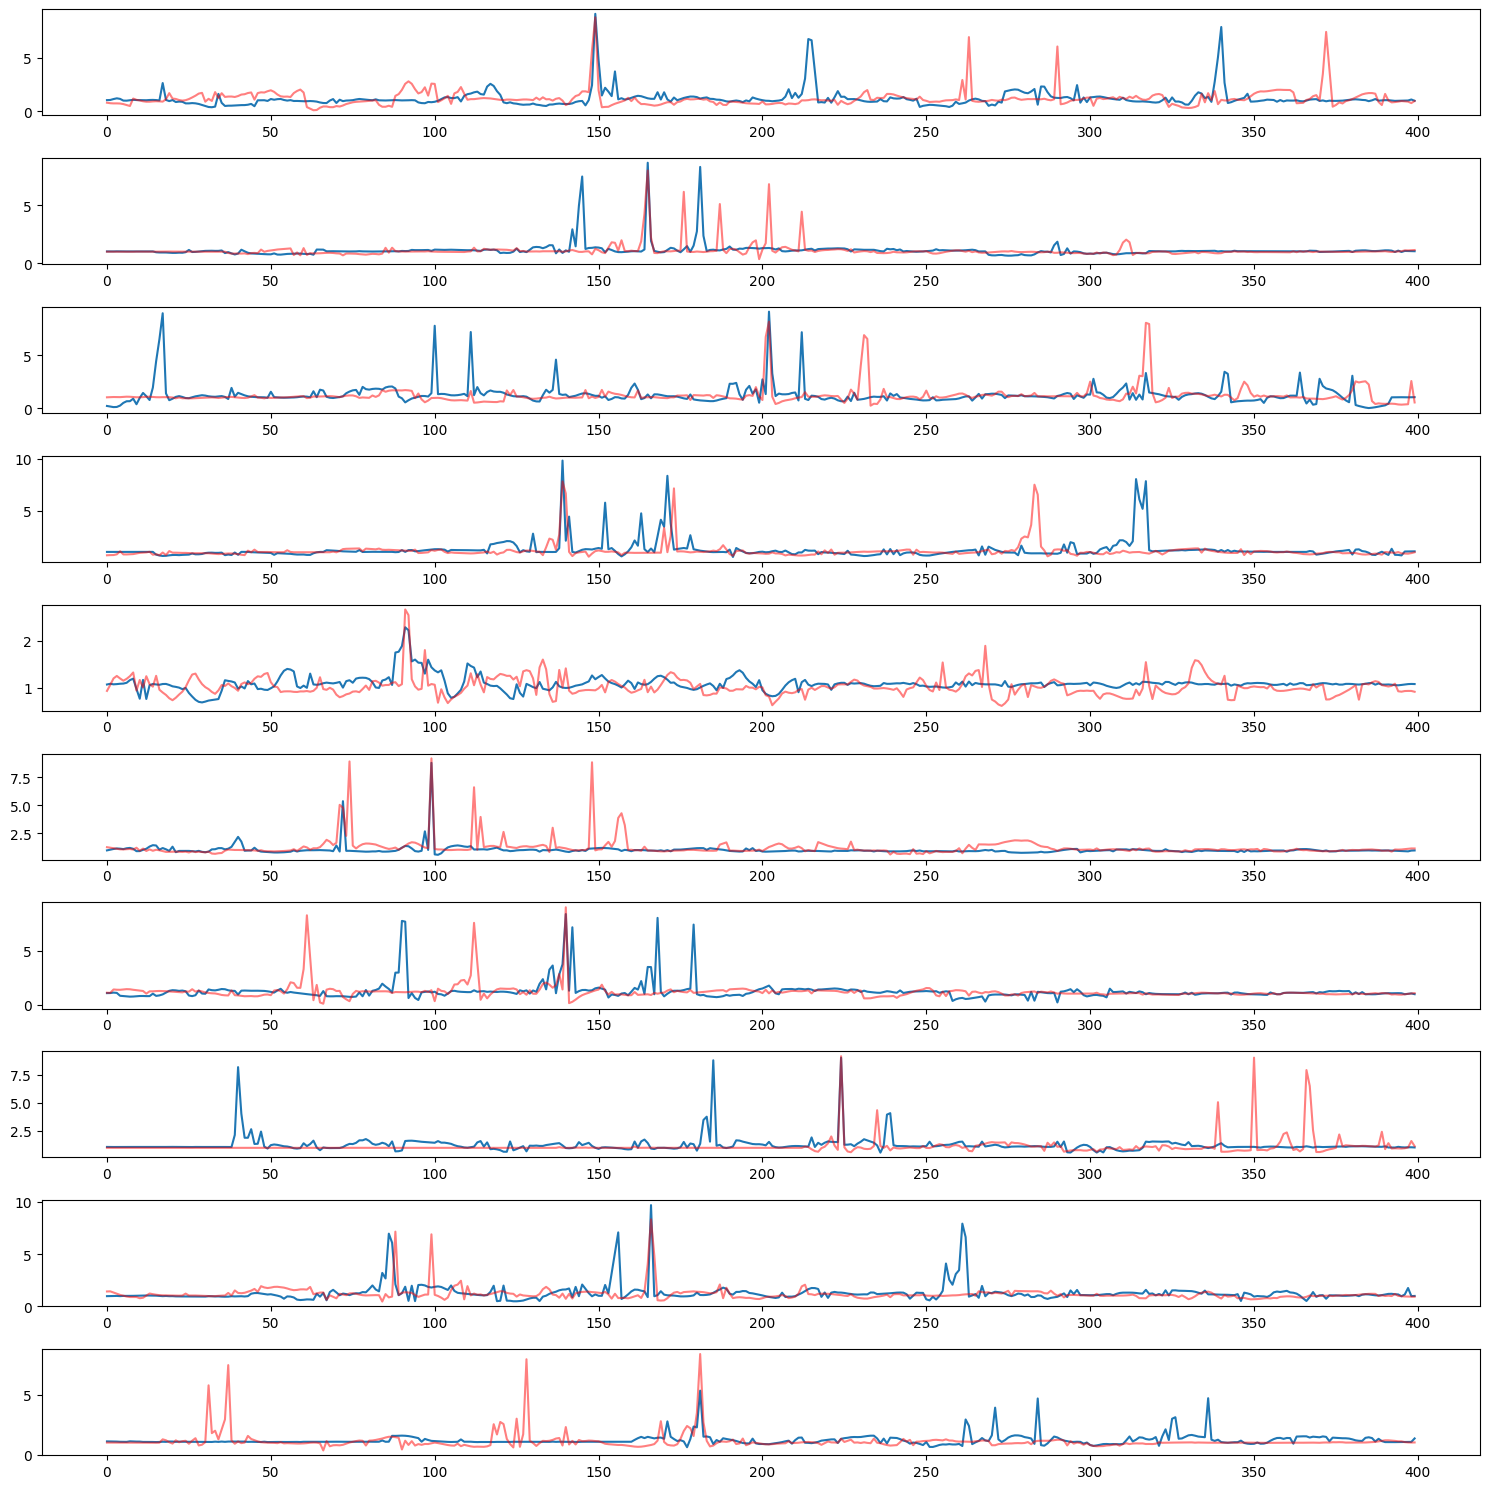

In [5]:
fig, ax = plt.subplots(10, 1, figsize=(15, 15))
for axis, (dfL, dfR) in zip(ax, dfs_synced):
    dfL["acc_mag"][:400].plot(ax=axis)
    dfR["acc_mag"][:400].plot(ax=axis, color="r", alpha=0.5)

plt.tight_layout()

In [6]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd

class FourLineCutter:
    def __init__(self, dfL, dfR, exercise_id):
        self.dfL = dfL
        self.dfR = dfR
        self.feature_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)
        
        # Hintergründe plotten
        self.ax1.plot(dfL.index, dfL["acc_mag"], color="royalblue", lw=1, label="Links")
        self.ax2.plot(dfR.index, dfR["acc_mag"], color="darkorange", lw=1, label="Rechts")
        
        self.ax1.set_title(f"High-Speed Cutting: {exercise_id}")
        self.ax1.legend()

        # Initiale Positionen
        idx = dfL.index
        pos = [idx[int(len(idx)*p)] for p in [0.1, 0.2, 0.7, 0.8]]
        
        self.lines = []
        self.active_line = None
        
        # 4 Linien-Paare erstellen (immer 2 pro Zeitpunkt: eine oben, eine unten)
        # Wir speichern sie als Paare, um sie später synchronisieren zu können
        colors = ['red', 'red', 'green', 'green']
        self.line_pairs = []
        
        for p, col in zip(pos, colors):
            l1 = self.ax1.axvline(p, color=col, lw=2, picker=10)
            l2 = self.ax2.axvline(p, color=col, lw=2, picker=10)
            self.line_pairs.append([l1, l2])
            self.lines.extend([l1, l2])

        # Event-Binding
        self.fig.canvas.mpl_connect('pick_event', self.on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)

        plt.tight_layout()
        
        # Blitting-Vorbereitung: Hintergrund speichern
        self.bg = None
        self.fig.canvas.draw()

    def on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist
            # Den Hintergrund ohne die Linien "einfrieren" für flüssiges Ziehen
            # (In Jupyter/Widget manchmal schwierig, daher nutzen wir hier die simple Variante,
            # reduzieren aber die Redraw-Last)

    def on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # Nur die aktuell gezogene Linie updaten
            self.active_line.set_xdata([event.xdata, event.xdata])
            # draw_idle ist effizienter als draw()
            self.fig.canvas.draw_idle() 

    def on_release(self, event):
        if self.active_line:
            curr_x = self.active_line.get_xdata()
            # Partner finden und nachziehen (nach dem Loslassen)
            for pair in self.line_pairs:
                if self.active_line in pair:
                    pair[0].set_xdata(curr_x)
                    pair[1].set_xdata(curr_x)
            
            self.active_line = None
            self.fig.canvas.draw_idle()

    def get_data(self):
        # Positionen extrahieren
        x_red = sorted([self.line_pairs[0][0].get_xdata()[0], self.line_pairs[1][0].get_xdata()[0]])
        x_green = sorted([self.line_pairs[2][0].get_xdata()[0], self.line_pairs[3][0].get_xdata()[0]])
        
        def cut(range_x):
            s, e = range_x
            # Nutze .loc für schnelles Slicing
            cL = self.dfL.loc[s:e, self.feature_cols]
            cR = self.dfR.loc[s:e, self.feature_cols]
            combined = pd.concat([cL, cR], axis=1, join='inner')
            return combined

        return cut(x_red), cut(x_green)


### Manual extraction

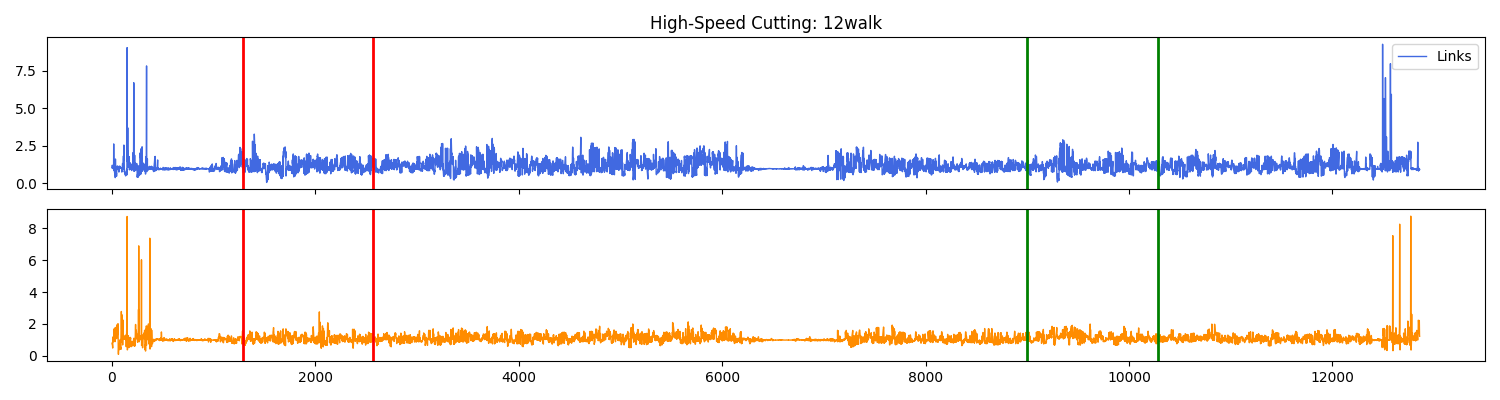

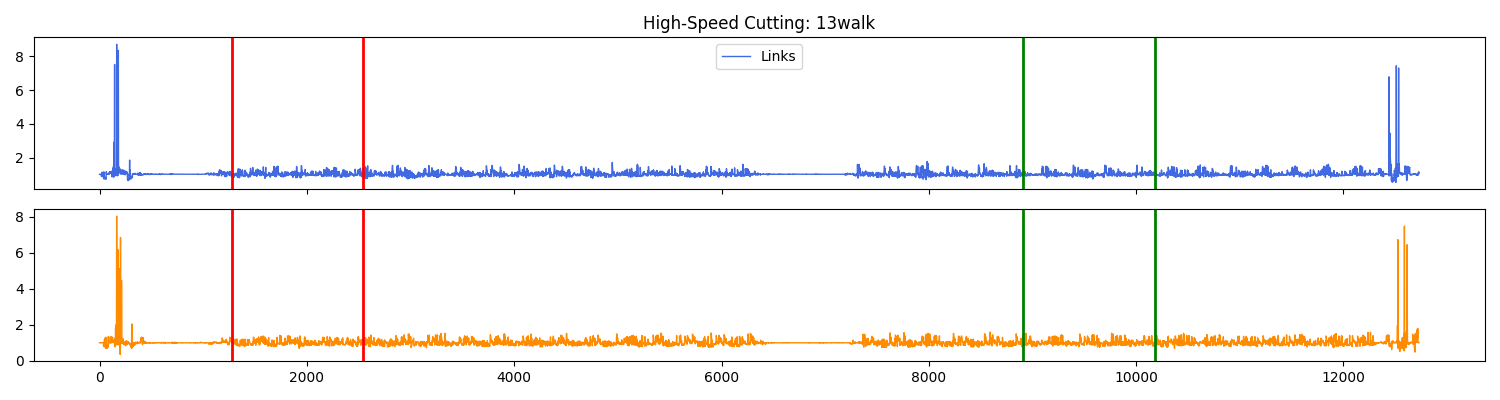

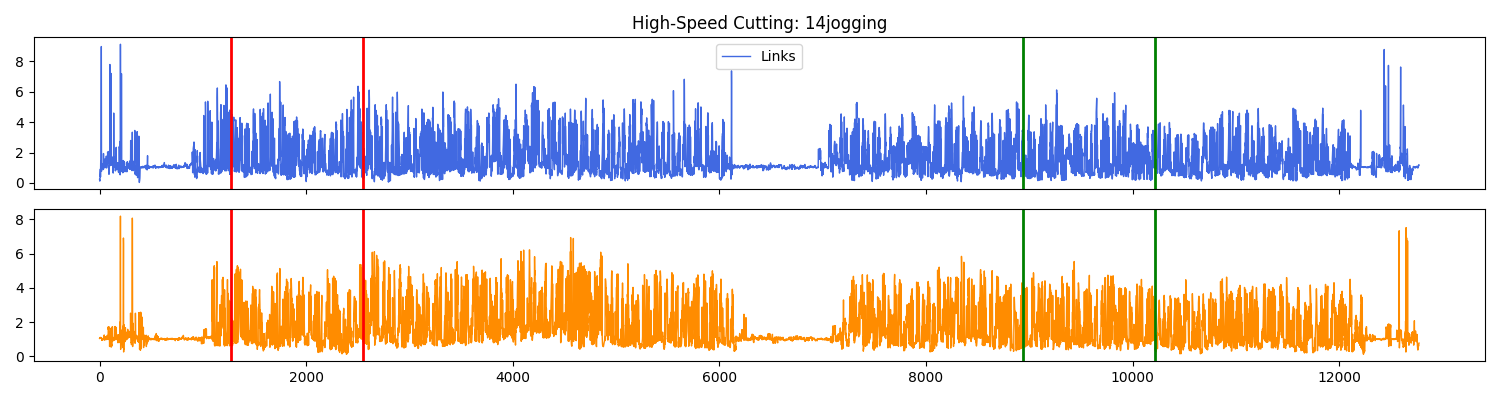

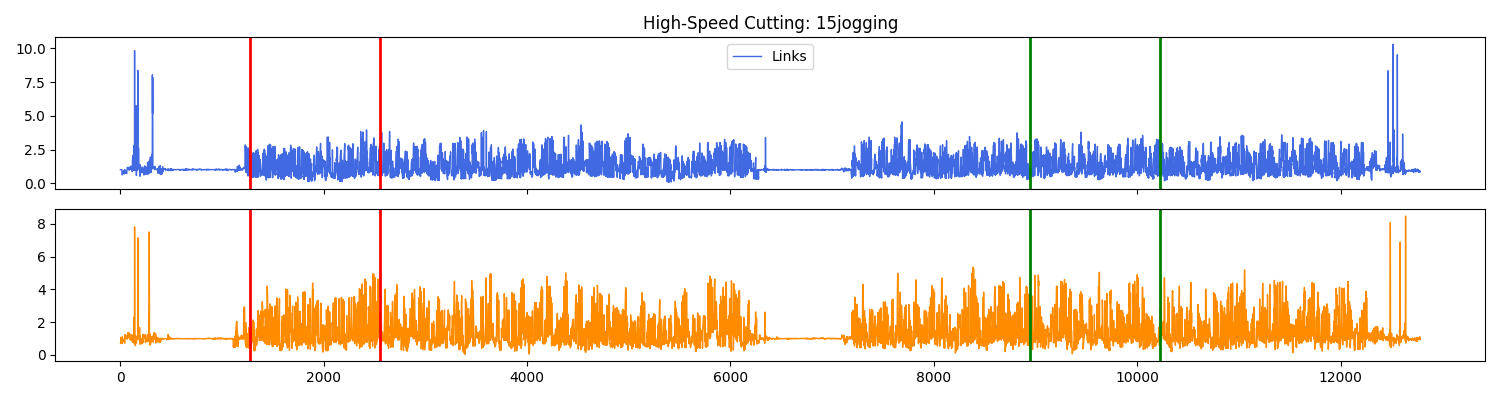

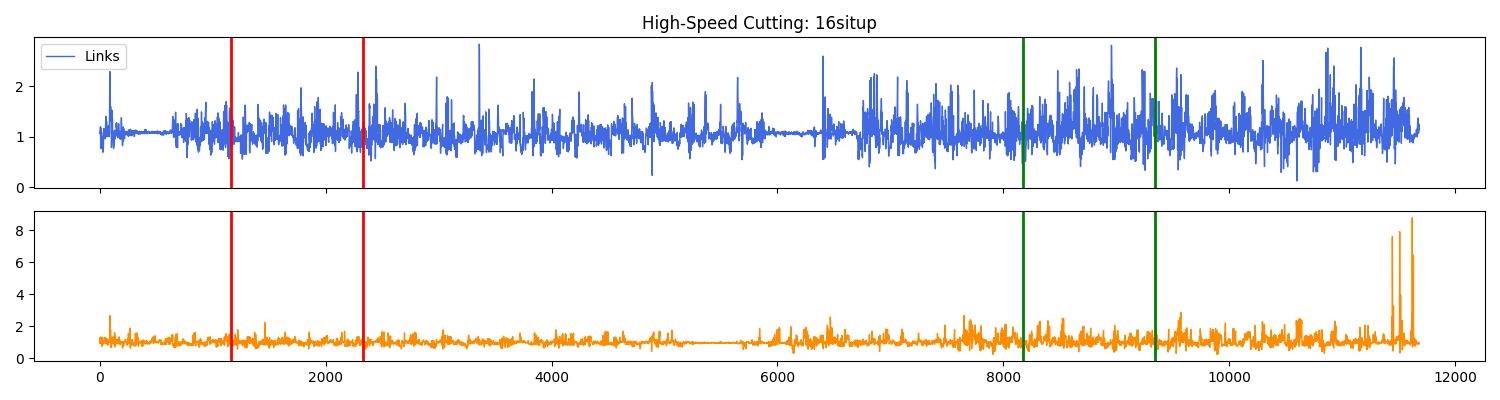

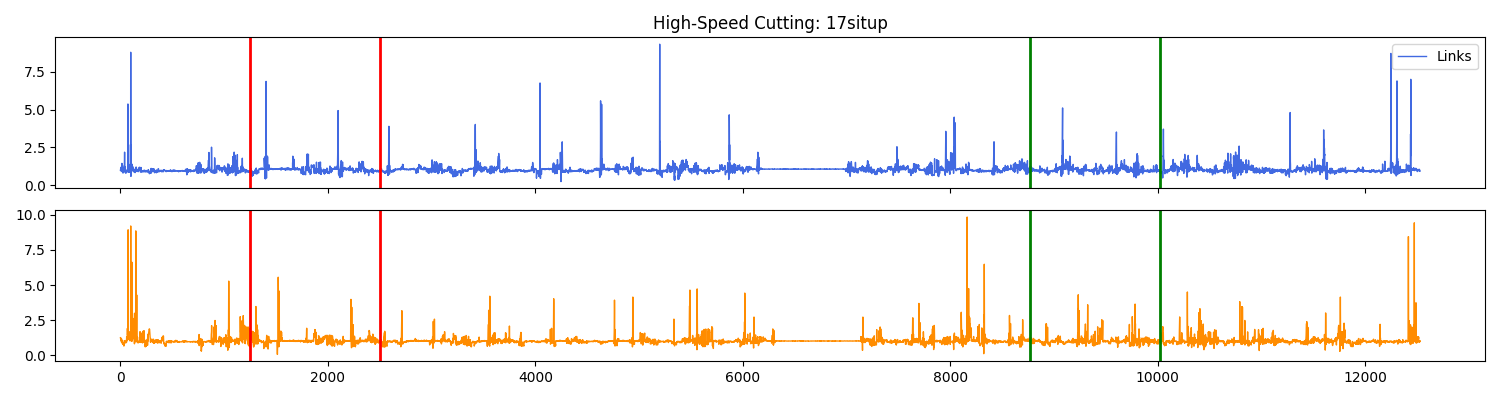

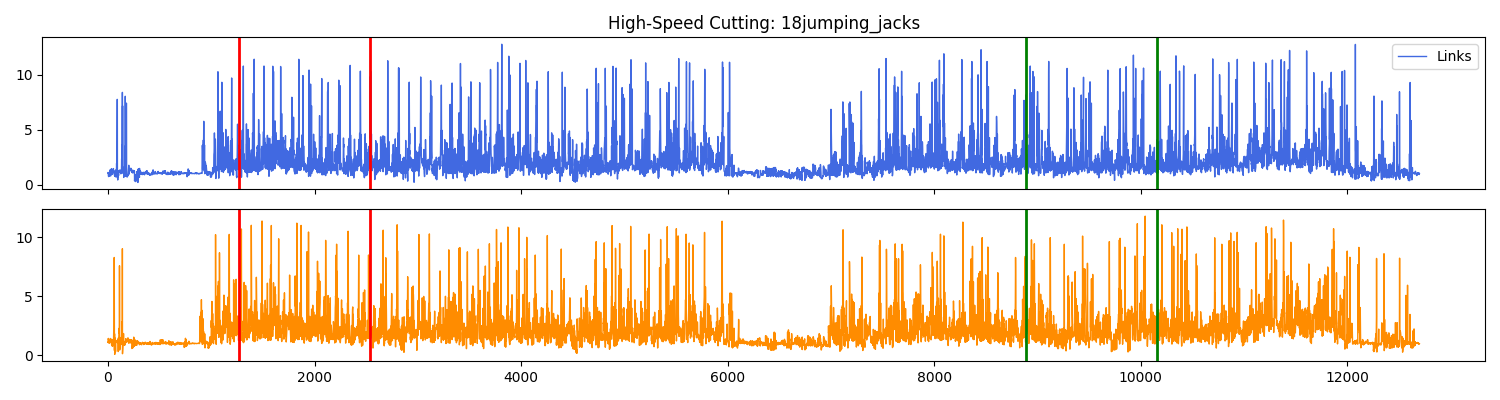

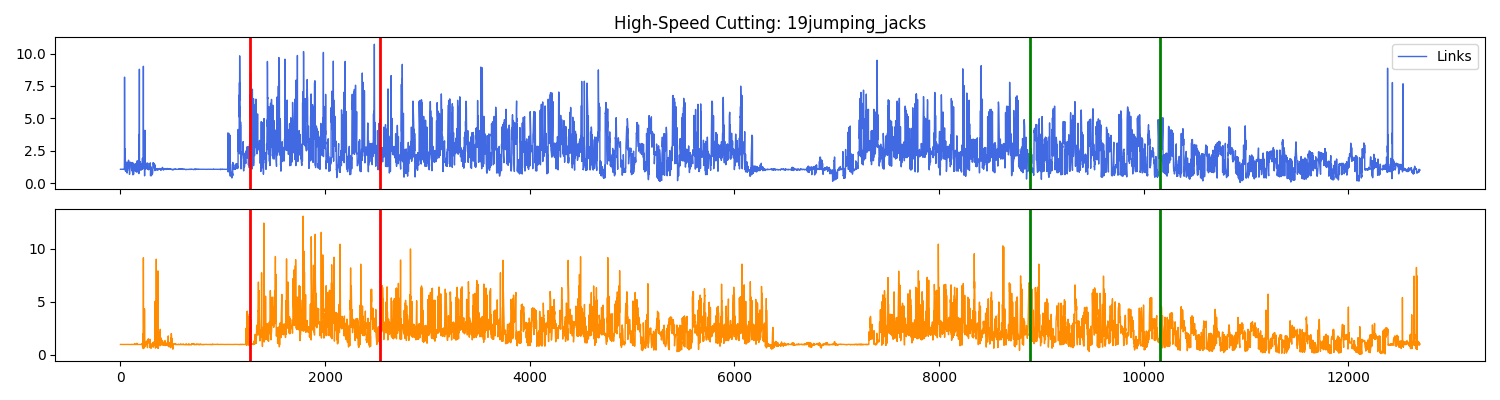

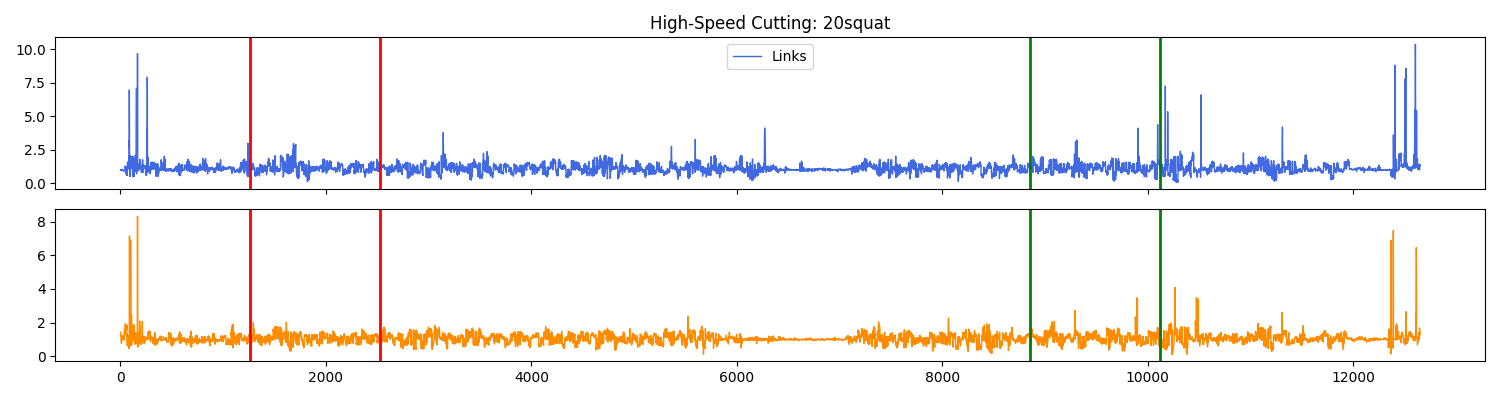

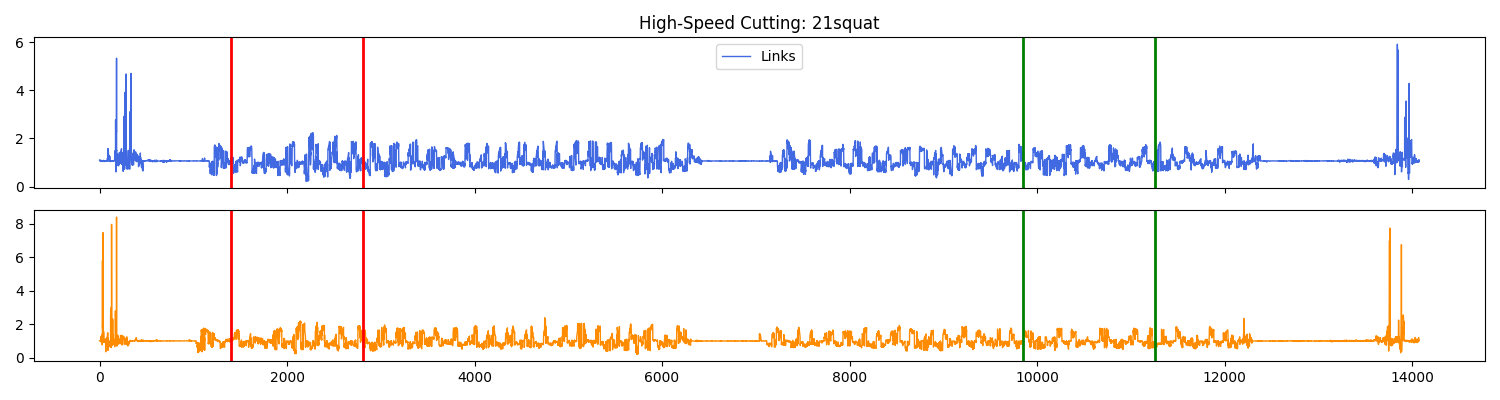

In [7]:
cutters = [FourLineCutter(dfL, dfR, str(id)+default_session_to_activity()[int(id)]) for id, (dfL, dfR) in enumerate(dfs_synced, start=12)]

In [8]:
tensors = [c.get_data() for c in cutters]

### Save the files

In [9]:
if not os.path.exists(ACTIVE_SECTIONS_DATA_ROOT):
    os.mkdir(ACTIVE_SECTIONS_DATA_ROOT)
    
for (t1, t2), id in zip(tensors, range(12, 22)):
    _path = os.path.join(ACTIVE_SECTIONS_DATA_ROOT, str(id))
    if _path + "part1.csv" not in os.listdir(ACTIVE_SECTIONS_DATA_ROOT):
        t1.to_csv(_path + "part1.csv", index=False)
        t2.to_csv(_path + "part2.csv", index=False)